# Crawl Overview: Fetch Outcomes, Category Distribution, Extraction Completeness

**Research question.** Given a diverse sample of real animal-rescue-related URLs, how
does the pipeline classify them (`STATION` / `LIST` / `IRRELEVANT`), how often does
fetching itself succeed, and - for pages the LLM decides are worth extracting data from -
how complete is the extracted record relative to the full field schema in `bot.config`?

**Data.** Produced by `experiments/collect_crawl_metrics.py`, which runs the real
fetch -> categorize -> extract pipeline (real Playwright fetches, the project's
configured LLM and category/field schema) over one URL per distinct domain from
`starting_urls.csv`, in file order (see the script's docstring for the exact selection
rule). This run is a small (n=6), uncapped sample - the model sees each page's full real
content, matching the production pipeline, rather than an earlier, larger (n=16) run that
used a fixed-length content cap for tractability (see `workflow_timing.ipynb`'s intro for
why that cap was dropped).

In [2]:
import sys
sys.path.insert(0, ".")
from plotting import set_style, savefig, load_csv, PALETTE, integer_axis
import matplotlib.pyplot as plt
import pandas as pd
import json

set_style()
df = load_csv("crawl_metrics.csv")
df["fetch_success"] = df["fetch_success"].astype(bool)
df

,url,domain,fetch_seconds,fetch_success,html_bytes,categorize_seconds,category,cleaned_text_chars,extract_seconds,extracted_count,extracted_json,extract_error
0,https://rlp.nabu.de/tiere-und-pflanzen/tieren-...,rlp.nabu.de,10.716,True,90583,226.673,LIST,23113.0,454.325,8.0,"[{""station_url"": ""https://rlp.nabu.de/tiere-un...",NaN
1,https://www.vbu-ffm.de/pflegestationen.shtml,www.vbu-ffm.de,1.395,True,29328,156.516,LIST,13746.0,1014.522,36.0,"[{""station_url"": ""http://www.wildtierhilfe-sch...",NaN
2,https://deutsche-wildtierrettung.de/wildtierau...,deutsche-wildtierrettung.de,3.137,True,128372,84.906,LIST,8706.0,343.472,12.0,"[{""station_url"": ""http://www.waldhaus-potsdam....",NaN
3,https://marswildliferescue.com/,marswildliferescue.com,3.563,True,586032,62.518,STATION,7870.0,101.496,14.0,"{""station_url"": ""https://marswildliferescue.co...",NaN
4,https://wp.wildvogelhilfe.org/auffangstationen...,wp.wildvogelhilfe.org,0.556,False,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,http://www.greifvogelhilfe.de//greifvogelhilfe,www.greifvogelhilfe.de,2.157,True,39737,52.945,STATION,8769.0,120.827,14.0,"{""station_url"": ""http://www.greifvogelhilfe.de...",NaN


## Fetch outcomes

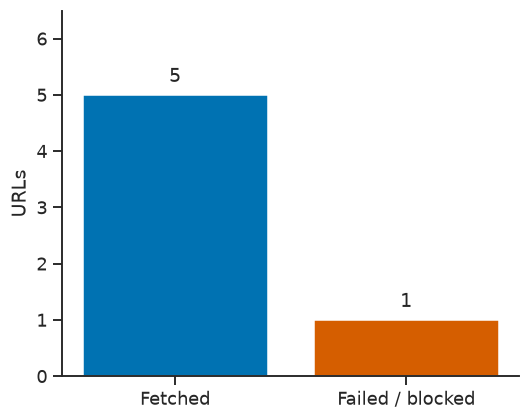

Caption: Fetch outcomes for the n=6 sampled URLs (one per distinct domain in starting_urls.csv).


In [3]:
outcome_counts = df["fetch_success"].map({True: "Fetched", False: "Failed / blocked"}).value_counts()
n_total = len(df)

fig, ax = plt.subplots(figsize=(5, 4))
ax.bar(outcome_counts.index, outcome_counts.values, color=[PALETTE[0], PALETTE[1]])
for i, v in enumerate(outcome_counts.values):
    ax.text(i, v + 0.15, str(v), ha="center", va="bottom")
ax.set_ylabel("URLs")
integer_axis(ax)
ax.set_ylim(0, outcome_counts.max() + 1.5)
fig.tight_layout()
savefig(fig, "fetch_outcomes")
plt.show()
print(f"Caption: Fetch outcomes for the n={n_total} sampled URLs (one per distinct domain "
      f"in starting_urls.csv).")

## Category distribution

Only successfully-fetched pages reach the categorization step, so the distribution below
is conditioned on `fetch_success`.

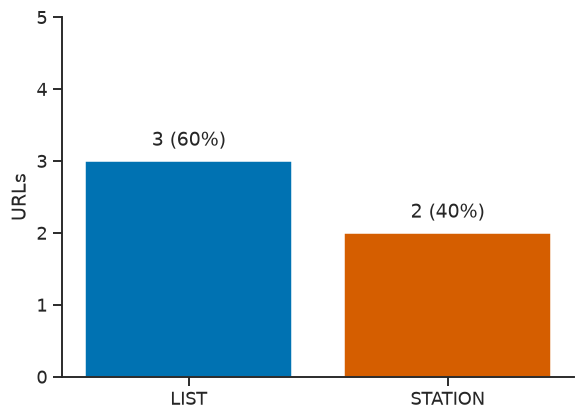

Caption: Assigned category for the n=5 successfully fetched pages (of 6 sampled).


In [4]:
categorized = df[df["fetch_success"]]
category_counts = categorized["category"].value_counts()
n_cat = len(categorized)

fig, ax = plt.subplots(figsize=(5.5, 4))
colors = [PALETTE[i % len(PALETTE)] for i in range(len(category_counts))]
ax.bar(category_counts.index, category_counts.values, color=colors)
for i, v in enumerate(category_counts.values):
    pct = 100 * v / n_cat
    ax.text(i, v + 0.15, f"{v} ({pct:.0f}%)", ha="center", va="bottom")
ax.set_ylabel("URLs")
integer_axis(ax)
ax.set_ylim(0, category_counts.max() + 2)
fig.tight_layout()
savefig(fig, "category_distribution")
plt.show()
print(f"Caption: Assigned category for the n={n_cat} successfully fetched pages (of "
      f"{n_total} sampled).")

## Extraction completeness

For pages the LLM judged relevant (`STATION`/`LIST`), the extraction prompt explicitly
instructs it to *leave out* fields it cannot fill from the page content, rather than
guessing - so a missing key in the extracted JSON is a meaningful "not found" signal, not
a formatting artifact. This counts, across all relevant extractions, how often each
schema field ended up present.

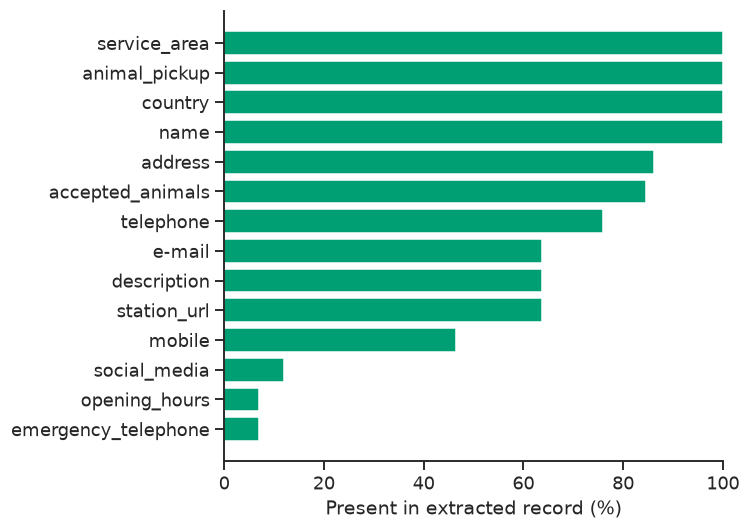

Caption: Field-level presence in extracted records (n=58 extracted record(s) from STATION/LIST pages) - how often each schema field was non-empty in the model's output.


In [5]:
ALL_FIELDS = [
    "station_url", "name", "address", "country", "e-mail", "telephone", "mobile",
    "emergency_telephone", "social_media", "accepted_animals", "service_area",
    "animal_pickup", "opening_hours", "description",
]

extracted_rows = df[df["extracted_json"].notna() & (df["extracted_json"] != "")]

field_presence = {f: 0 for f in ALL_FIELDS}
n_records = 0
for _, row in extracted_rows.iterrows():
    records = json.loads(row["extracted_json"])
    if isinstance(records, dict):
        records = [records]
    for record in records:
        n_records += 1
        for f in ALL_FIELDS:
            if record.get(f) not in (None, "", []):
                field_presence[f] += 1

if n_records:
    order = pd.Series(field_presence).sort_values(ascending=True)
    pct = order / n_records * 100

    fig, ax = plt.subplots(figsize=(7, 5))
    ax.barh(order.index, pct, color=PALETTE[2])
    ax.set_xlabel("Present in extracted record (%)")
    ax.set_xlim(0, 100)
    fig.tight_layout()
    savefig(fig, "extraction_completeness")
    plt.show()
    print(f"Caption: Field-level presence in extracted records (n={n_records} extracted "
          f"record(s) from STATION/LIST pages) - how often each schema field was "
          f"non-empty in the model's output.")
else:
    print("No extracted records in this sample - nothing to plot.")

## Discussion

**Category distribution.** With only a small, diverse sample, this is not a
statistically representative picture of the wider web of animal-rescue-related pages -
`starting_urls.csv` itself is already a curated, high-relevance list (see the README) -
but it does sanity-check that the categorization step actually discriminates between
categories rather than collapsing everything into one bucket, and gives a rough sense of
how much of a real crawl's traffic ends up worth extracting from at all.

**Extraction completeness.** Contact-style fields (name, address) are expected to be
filled far more often than niche fields (e.g. `emergency_telephone`, `social_media`),
which most station websites simply don't publish - low completeness for such a field is
evidence of the *page* lacking the information, not necessarily of the extraction step
failing.

**Note on sample size.** This run uses n=6 starting URLs rather than the earlier n=16 -
reduced deliberately so an uncapped run (see below) stays tractable, after a larger
uncapped attempt turned out to take multiple hours per LIST page. One of the six
(`wp.wildvogelhilfe.org`) is currently blocked by the target site's own bot-detection
(robots.txt returns a firewall block page rather than a real policy - see
`correctness_evaluation.ipynb`'s site-availability note) and is excluded from fetch
success onward. Percentages at this n should be read as illustrative, not precise.